# <span style="color: yellow;">Master Notebook</span>

This notebook contains our entire project, and should be capable of running from start to end without issue.  It has three main sections - one for our application of algorithms to the pretrained ResNet50, one for ResNet 18, and one for ResNet10t.  In each section, there will be sub-sections for each compression algorithm, and the results will be plotted at the end on a Pareto front.

Please paste your functions applying your compression technique in the appropriate section.  The final deliverable is a <ins>Pareto Front</ins> graph, so what you need to output from your model is its <ins>% size reduction</ins> (how much you decreased parameters) and <ins>F1 accuracy</ins> at that size.

**Table of Contents:**
1. Data Preparation: this section pulls the necessary dataset from huggingface and instantiates a pytorch dataset/loaders
2. Application of algorithms to ResNet50
3. Application of algorithms to ResNet18
4. Application of algorithms to ResNet10t

Within each of these application sections, there will be sub-sections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

In [71]:
# first we just ensure we are working in the right folder
import os
target_folder = "CS6423_knowledge_distillation_project"
path = os.path.join(os.getcwd(), target_folder)

if not os.getcwd().endswith(target_folder):
    os.chdir(path)

print(f"Current working directory: {os.getcwd()}")

Current working directory: /home/epoc2/scalable/CS6423_knowledge_distillation_project


## <span style="color: yellow;">1. Data Preparation</span>

This code downloads the dataset and pretrained models from HuggingFace and does a bit of cleaning. You will need to put a HF token with access to the required repositories into the first cell.  <span style="color: yellow;">Note: you only need to run these download cells once (or not at all if you already downloaded dataset)</span>

In [ ]:
# Fiachra - code that downloads the dataset and organizes the csv.
from huggingface_hub import login
login("your_code_here")

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm
import os

SAVE_DIR = "data/test_images"
NUM_TEST_IMGS = 10000
os.makedirs(SAVE_DIR, exist_ok=True)

ds = load_dataset(
    "raidium/RadImageNet-VQA",
    "alignment",
    split="val",
    streaming=True
)

subset = ds.shuffle(seed=42, buffer_size=30000).take(NUM_TEST_IMGS)

seen_images = set()
labels_path = "data/labels.csv"

with open(labels_path, "w", encoding="utf-8") as f:
    f.write("filename,pathology,modality,location,label\n")

    for i, row in enumerate(tqdm(subset, desc="Saving unique images", total=NUM_TEST_IMGS)):
        if not isinstance(row, dict):
            continue

        img_id = row.get("id", i)

        if img_id not in seen_images:
            img_filename = f"test_{img_id}.png"
            img_path = os.path.join(SAVE_DIR, img_filename)

            if not os.path.exists(img_path):
                row["image"].save(img_path)

            meta = row.get("metadata", {})
            pathology = meta.get("pathology", "unknown")
            modality = meta.get("modality", "unknown")
            location = meta.get("location", "unknown")
            label = f"{location}_{pathology}".replace(" ", "_")

            f.write(f"{img_filename},{pathology},{modality},{location},{label}\n")
            seen_images.add(img_id)

print(f"\nProcessing Complete!")
print(f"Total Unique Images: {len(seen_images)}")
print(f"Metadata saved to: {labels_path}")

total number of classes in dataset: 61
total datapoints in dataset: 9936


,filename,pathology,modality,location,label
0,test_0.png,soft_tissue_fluid,mri,ankle foot,ankle_foot_soft_tissue_fluid
1,test_1.png,osseous_disruption,mri,ankle foot,ankle_foot_osseous_disruption
2,test_2.png,chondral_abnormality,mri,ankle foot,ankle_foot_chondral_abnormality
3,test_3.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_
4,test_4.png,achilles_pathology_,mri,ankle foot,ankle_foot_achilles_pathology_


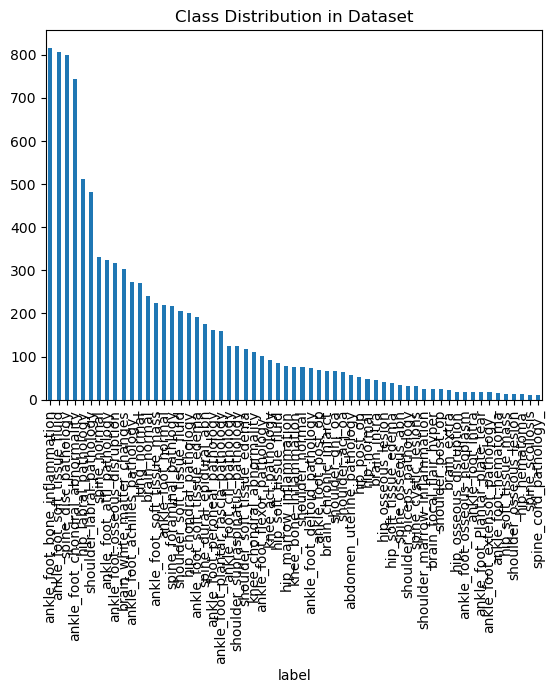

In [2]:
import pandas as pd

test_df = pd.read_csv("data/labels.csv")
label_counts = test_df['label'].value_counts()
label_counts.plot(kind='bar', title='Class Distribution in Dataset')

large_classes = label_counts[label_counts > 10].index
drop_classes_df = test_df[test_df['label'].isin(large_classes)]
num_classes = drop_classes_df.label.value_counts().shape[0]

print(f"total number of classes in dataset: {num_classes}")
print(f"total datapoints in dataset: {len(drop_classes_df)}")
drop_classes_df.to_csv("data/labels.csv", index=False)
df = pd.read_csv('data/labels.csv')

df.head()

Here we prepare the dataset using Fiachra's modules.  <span style="color: yellow;">This cell needs to be run every time.</span>

In [72]:
# Fiachra - instantiate the dataset/dataloaders through the datasetPrepper
import pandas as pd
from modules.dataset_prepper import datasetPrepper

# sets path variables
pretrained_weights_path = "RadImageNet_weights/resnet50.pth"
dataframe_path = "data/labels.csv"
image_dir = "data/test_images"
model_name = "resnet50_baseline_cpu"

# loads dataset csv
dataframe = pd.read_csv(dataframe_path)
num_classes = dataframe["label"].nunique()

# prepare dataset with datasetPrepper module, print confirmations
data_prep = datasetPrepper(
    dataframe_path="data/labels.csv",
    image_dir="data/test_images",
).prepare(compute_class_weights=True)

print(f"Dataset prepared:")
print(f"  Train samples: {len(data_prep.train_dataset)}")
print(f"  Val samples: {len(data_prep.val_dataset)}")
print(f"  Test samples: {len(data_prep.test_dataset)}")
print(f"  Classes: {len(data_prep.class_names)}")

Dataset prepared:
  Train samples: 7948
  Val samples: 1590
  Test samples: 398
  Classes: 61


# <span style="color: yellow;">Algorithm Application to ResNet50</span>
This section applied all of our KD algorithms to a pretrained ResNet50.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: yellow;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [4]:
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="fiabar/cs6423_model_repo",
    repo_type="model",
    local_dir=os.path.join(os.getcwd(), 'trained_models/')
)

Fetching 177 files:   0%|          | 0/177 [00:00<?, ?it/s]

'/home/cor10/CS6423_knowledge_distillation_project/trained_models'

Here we instantiate the pretrained ResNet50 and run an inference pass for the baseline.

In [73]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    "./trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet50 = resnet50.to(device)
resnet50.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet50.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet50, "ResNet50 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet50 gpu new...
Running inference...
Our F1 score: 0.49377259670043605
Our total parameters: 23633021


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## <span style="color: yellow;">b. Basic Compression Algorithms</span>

### Initializing our experiment tracker
Here we define a function that can append the results from each model compression algorithm to a dataframe for our Pareto Front visualization.  The tracker has:
* method: the method you used for compression (e.g., LTH, RGP, NAS+KD, etc.)
* base_model: the name of the model you are compressing (e.g., resnet10, resnet18, resnet50) 
* base_size: the number of parameters in the basic model
* compressed_size: the number of parameters in the model you compressed
* f1: the F1 score your compressed model has 

So, after you run each experiment, have something that looks like:

In [6]:
'''
Method = 'Pruning'
Base_Model = 'resnet10'
Base_Model_Parameters = 2012345
New_Model_Parameters = 2002345
F1_Score = 0.8
add_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)
'''

"\nMethod = 'Pruning'\nBase_Model = 'resnet10'\nBase_Model_Parameters = 2012345\nNew_Model_Parameters = 2002345\nF1_Score = 0.8\nadd_experiment(Method, Base_Model, Base_Model_Parameters, New_Model_Parameters, F1_Score)\n"

In [74]:
# initialize a dataframe we will append our results to
import pandas as pd
results_df = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df = pd.concat([results_df, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet50', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.494


In [75]:
# Code or functions that apply basic pruning
from torch.nn.utils import prune
import copy

def random_prune(model, amount):
    # apply ranodm unstructured pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.random_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'randomized unstructured pruning applied with amount: {amount}')

def magnitude_prune(model, amount):
    # apply random magnitude pruning
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
            prune.l1_unstructured(module, name='weight', amount=amount)
            prune.remove(module, 'weight')
    #print(f'magnitude pruning applied with amount: {amount}')


pruning_amounts = [0.1, 0.25, 0.5, 0.75, 0.9]
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

for amount in pruning_amounts:
    # initialize model copies
    model_random_pruned = copy.deepcopy(resnet50)
    model_magnitude_pruned = copy.deepcopy(resnet50)
    
    # apply prunings and record results
    random_prune(model_random_pruned, amount)
    metrics = evaluator.evaluate_single(model_random_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method=f'Random Pruning {amount}', 
                   base_model='resnet50',
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])
    
    magnitude_prune(model_magnitude_pruned, amount)
    metrics = evaluator.evaluate_single(model_magnitude_pruned)
    #print(f'RANDOM PRUNE: Our F1 score: {metrics['f1_macro']}\n Our total parameters: {metrics['total_parameters']}')
    add_experiment(method=f'Magnitude Pruning {amount}', 
                   base_model='resnet50', 
                   base_size=base_model_metrics['total_parameters'], 
                   compressed_size=metrics['total_parameters'], 
                   f1=metrics['f1_macro'])

display(results_df)

Logged: Random Pruning 0.1 | Reduction: 10.0% | F1: 0.017


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Magnitude Pruning 0.1 | Reduction: 10.0% | F1: 0.497


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning 0.25 | Reduction: 24.9% | F1: 0.001


...

/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning 0.75 | Reduction: 74.8% | F1: 0.000
Logged: Magnitude Pruning 0.75 | Reduction: 74.8% | F1: 0.037


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logged: Random Pruning 0.9 | Reduction: 89.8% | F1: 0.002
Logged: Magnitude Pruning 0.9 | Reduction: 89.8% | F1: 0.003


,Method,Base_Model,Size_Reduction_Pct,F1_Score
0,N/A,resnet50,0.0,0.4938
1,Random Pruning 0.1,resnet50,9.98,0.0166
2,Magnitude Pruning 0.1,resnet50,9.98,0.4967
3,Random Pruning 0.25,resnet50,24.94,0.0008
4,Magnitude Pruning 0.25,resnet50,24.94,0.4947
5,Random Pruning 0.5,resnet50,49.89,0.0011
6,Magnitude Pruning 0.5,resnet50,49.89,0.4294
7,Random Pruning 0.75,resnet50,74.83,0.0003
8,Magnitude Pruning 0.75,resnet50,74.83,0.0369
9,Random Pruning 0.9,resnet50,89.8,0.0017


### Basic Pruning and Quantization

In [76]:
from torchao.quantization import quantize_, Int8DynamicActivationInt8WeightConfig

def fp16_cast(model):
    return model.to(torch.float16)

def int8_dyn(model):
    quantize_(model, Int8DynamicActivationInt8WeightConfig())
    return model

def int8_and_fp16(model):
    model = model.to(torch.float16)
    quantize_(model, Int8DynamicActivationInt8WeightConfig())
    return model

quant_funcs = {
    "INT8_Dyn": int8_dyn,
    "FP16": fp16_cast,
    "INT8 and FP16": int8_and_fp16
}

In [77]:
from quantisation_suite import run_quantisation_suite
from modules import ModelEvaluator

evaluator = ModelEvaluator(
    data_loader=data_prep.val_loader,
    class_names=data_prep.class_names
)

eval = run_quantisation_suite("ResNet50", resnet50, evaluator, quant_funcs)

--- Running on: CUDA ---
Preparing ResNet50_INT8_Dyn...
Preparing ResNet50_FP16...
Preparing ResNet50_INT8 and FP16...
Sending 4 models to the evaluator...

[Evaluating] ResNet50_Baseline_FP32...

Warming up ResNet50_Baseline_FP32...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

[Evaluating] ResNet50_INT8_Dyn...

Warming up ResNet50_INT8_Dyn...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

[Evaluating] ResNet50_FP16...

Warming up ResNet50_FP16...
Running inference...

[Evaluating] ResNet50_INT8 and FP16...

Warming up ResNet50_INT8 and FP16...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

+------------------------+------------+---------------------+--------------------+-------------------------+
| Model                  |   F1 Macro |   cuda Latency (ms) |   Actual Size (mb) |   Theoretical Size (mb) |
+========================+============+=====================+====================+=========================+
| ResNet50_Baseline_FP32 |       0.49 |                1.29 |              90.36 |                   90.36 |
+------------------------+------------+---------------------+--------------------+-------------------------+
| ResNet50_INT8_Dyn      |       0.49 |                1.45 |              90.36 |                   90.36 |
+------------------------+------------+---------------------+--------------------+-------------------------+
| ResNet50_FP16          |       0.49 |                0.77 |              45.18 |                   45.18 |
+------------------------+------------+---------------------+--------------------+------------------------

In [78]:
base_model_size = eval.results['ResNet50_Baseline_FP32']['model_size_mb']

for name, results in eval.results.items():
    add_experiment(method=f'Quantisation {name}', 
                       base_model='resnet50',
                       base_size=base_model_size, 
                       compressed_size=results['model_size_mb'],
                       f1=results['f1_macro'])

Logged: Quantisation ResNet50_Baseline_FP32 | Reduction: 0.0% | F1: 0.487
Logged: Quantisation ResNet50_INT8_Dyn | Reduction: 0.0% | F1: 0.488
Logged: Quantisation ResNet50_FP16 | Reduction: 50.0% | F1: 0.487
Logged: Quantisation ResNet50_INT8 and FP16 | Reduction: 50.0% | F1: 0.489


### Caylum - Lottery Ticket Hypothesis
This is a varient of the lottery ticket hypothesis known as weight resetting. Essentially, since we cannot get access to the original weight initialisation, we use the weights prior to fine tuning on our data set as the initial weights, and use those as the original weights.

In [79]:
# For ease, we set weights to zero instead of removing them outright so we use this function to count effective paramaters.
def count_effective_params(model):
    total = 0
    nonzero = 0
    
    for p in model.parameters():
        total += p.numel()
        nonzero += (p != 0).sum().item()
    
    return total, nonzero

In [83]:
import torch as T
import torch.nn.utils.prune as prune
from torchvision import models
import numpy as np
from modules import ImagenetLoader, datasetPrepper, modelTrainer, ModelEvaluator
import pandas as pd


# We need the weights path
lth_pretrained_weights_path = "RadImageNet_weights/resnet50.pth"

# Define the evaluator
lth_evaluator = ModelEvaluator(data_prep.val_loader, data_prep.class_names)
lth_loader = ImagenetLoader()
lth_eval_stats = {}
lth_param_counts = {}

# Define the pruning percentages
pruning_percentages = [10, 25, 50, 75, 90]

# Now loop for all pruning percentages
for p_percent in pruning_percentages:
    print(f"\nLTH for {p_percent}%")
    
    # Reset Weights at the start of every cycle
    lth_loader.load_radimagenet_resnet50(lth_pretrained_weights_path)
    lth_model = lth_loader.model
    
    # Train the parent model
    lth_trainer = modelTrainer(
        model=lth_model,
        data_prep=data_prep,
        device=None,
        learn_rate=0.001,
        num_epochs=10,
        model_name=f"parent_lth_{p_percent}",
    )
    lth_trainer.prepare_for_training(trainable_params=lth_loader.get_trainable_params())
    lth_trainer.train_all()
    
    # Get the pruning mask from the parent model
    lth_model.eval()
    masks = {}
    
    for name, module in lth_model.named_modules():
      if isinstance(module, (T.nn.Linear, T.nn.Conv2d)):
        prune.l1_unstructured(module, name='weight', amount=p_percent / 100.0)
        masks[name] = (module.weight_mask).cpu()
        prune.remove(module, 'weight')

    # Reset Weights
    lth_loader.load_radimagenet_resnet50(lth_pretrained_weights_path)
    lth_model = lth_loader.model
    lth_trainer = modelTrainer(
        model=lth_model,
        data_prep=data_prep,
        device=None,
        learn_rate=0.001,
        num_epochs=10,
        model_name=f"lth_{p_percent}",
    )

    # Apply the mask by directly setting weights to zero where mask is zero
    with T.no_grad():
      for name, module in lth_model.named_modules():
        if isinstance(module, (T.nn.Linear, T.nn.Conv2d)) and name in masks:
            module.weight.data.mul_(masks[name])
            prune.custom_from_mask(module, name='weight', mask=masks[name])
            prune.remove(module, 'weight')
    
    # Train that ticket
    print(f"Training ticket for {p_percent}% LTH pruning...")
    lth_model.train()
    lth_trainer.prepare_for_training(trainable_params=lth_loader.get_trainable_params())
    lth_trainer.train_all()

    # Evaluate that ticket
    lth_model.eval()
    lth_metrics = lth_evaluator.evaluate_single(lth_model)
    lth_total, lth_non_zero = count_effective_params(lth_model)
    
    # Add in the experiment
    add_experiment(method=f'LTH {p_percent}', 
               base_model='resnet50', 
               base_size=lth_total, 
               compressed_size=lth_non_zero, 
               f1=lth_metrics['f1_macro'])

    print(f"\n======================\nDone for %{p_percent}\n======================\n")


LTH for 10%



Epoch 1/10: 100%|██████████| 249/249 [00:33<00:00,  7.34batch/s, loss=0.322]

Validating: 100%|██████████| 50/50 [00:03<00:00, 15.32batch/s]



Epoch 1/10
Train Loss: 1.0550 | Train F1: 0.3937
Val Loss: 1.7744 | Val F1: 0.3239
Epoch Time: 37.18s




Epoch 2/10: 100%|██████████| 249/249 [00:33<00:00,  7.38batch/s, loss=0.478]

Validating: 100%|██████████| 50/50 [00:03<00:00, 15.48batch/s]



Epoch 2/10
Train Loss: 0.3326 | Train F1: 0.6449
Val Loss: 1.7559 | Val F1: 0.3678
Epoch Time: 36.98s



...

Validating: 100%|██████████| 50/50 [00:03<00:00, 15.37batch/s]



Epoch 9/10
Train Loss: 0.8631 | Train F1: 0.3491
Val Loss: 2.9391 | Val F1: 0.1244
Epoch Time: 36.88s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.41batch/s]


Epoch 10/10
Train Loss: 0.7263 | Train F1: 0.3742
Val Loss: 2.9591 | Val F1: 0.1401
Epoch Time: 36.83s


Warming up Model...


Running inference...
Logged: LTH 90 | Reduction: 32.4% | F1: 0.140

Done for %90



### Kellie - RGP
Code/functions that apply RGP and output a few datapoints for the Pareto Front. RGP iteratively removes the least important convolution filters from ResNet50 using gradient-based importane scorea, sheinking the model in 5 steps from 10% to 50% sparsity. After each pruning step the model is fine-tunes to recover accuracy, trading off model size against F1 score acrpss 5 Pareto front points.

In [84]:
# Kellie - RGP: Rigorous Gradient-based Pruning
# Results loaded from pre-trained checkpoints saved by rgp.ipynb
# Models were trained with iterative structured pruning (DFOT scoring) across
# 5 sparsity levels (10%-50%), fine-tuned for 10 epochs each to recover accuracy.

import os
import torch
import pandas as pd

rgp_checkpoints = {
    '10%': 'trained_models/rgp_step_0.1/rgp_step_0.1_full.pth',
    '20%': 'trained_models/rgp_step_0.2/rgp_step_0.2_full.pth',
    '30%': 'trained_models/rgp_step_0.3/rgp_step_0.3_full.pth',
    '40%': 'trained_models/rgp_step_0.4/rgp_step_0.4_full.pth',
    '50%': 'trained_models/rgp_step_0.5/rgp_step_0.5_full.pth',
}

initial_params = sum(p.numel() for p in resnet50.parameters())
rgp_step_metrics = []

for sparsity, path in rgp_checkpoints.items():
    print(f"Loading RGP {sparsity} model from {path}...")

    rgp_model = torch.load(path, map_location=device, weights_only=False)['model']
    rgp_model = rgp_model.to(device)
    rgp_model.eval()

    step_metrics = evaluator.evaluate_single(rgp_model, f"RGP_{sparsity}")
    step_params  = sum(p.numel() for p in rgp_model.parameters())

    add_experiment(
        method='RGP',
        base_model='resnet50',
        base_size=initial_params,
        compressed_size=step_params,
        f1=step_metrics['f1_macro']
    )

    rgp_step_metrics.append({
        'Sparsity': sparsity,
        'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

# Results summary table
summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
summary_df.index.name = 'RGP Step'
display(summary_df)

Loading RGP 10% model from trained_models/rgp_step_0.1/rgp_step_0.1_full.pth...

Warming up RGP_10%...
Running inference...
Logged: RGP | Reduction: 4.5% | F1: 0.375
Loading RGP 20% model from trained_models/rgp_step_0.2/rgp_step_0.2_full.pth...

Warming up RGP_20%...
Running inference...
Logged: RGP | Reduction: 7.2% | F1: 0.363
Loading RGP 30% model from trained_models/rgp_step_0.3/rgp_step_0.3_full.pth...

Warming up RGP_30%...
Running inference...
Logged: RGP | Reduction: 10.0% | F1: 0.384
Loading RGP 40% model from trained_models/rgp_step_0.4/rgp_step_0.4_full.pth...

Warming up RGP_40%...
Running inference...
Logged: RGP | Reduction: 12.6% | F1: 0.395
Loading RGP 50% model from trained_models/rgp_step_0.5/rgp_step_0.5_full.pth...

Warming up RGP_50%...
Running inference...
Logged: RGP | Reduction: 14.9% | F1: 0.377


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,4.53,0.3751,86.3,1.07
20%,7.16,0.3628,83.9,1.04
30%,10.01,0.3842,81.3,1.04
40%,12.64,0.3950,79.0,1.03
50%,14.94,0.3771,76.9,1.01


## <span style="color: yellow;">c. Knowledge Distillation Algorithms</span>


### Ethan - NAS + KD Algorithm
Here, we employ our NAS+KD algorithm.  The step-by-step process is shown in the NAS_KD_main.ipynb folder.  Complete details, code, and output logs are viewable there.  Here, we will simply import the trained student model, designed and distilled using NAS+KD, and evaluate it using the test data set.\

In [85]:
''' search space:
input resolution = [128, 160, 190, 224]
depth = [2, 3, 4]
width = [0.65, 0.8, 1.0, 1.2]
expansion ratio = [3,4,6]
'''
# define a ocnfig class for supernet training
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet50'

        # supernet init params
        self.supernet_res = [128, 160, 190, 224]
        self.supernet_width = [0.65, 0.8, 1.0, 1.2]
        self.supernet_expansion = [1.5, 2.0, 3.0]
        self.supernet_depth = [2, 3]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 3.0
        self.alpha = 0.5
        
        self.saver = 'supernet_resnet50_n'

In [86]:
# import modules that will load our supernet
from knowledge_distillation.model_init import Supernet_resnet50
from knowledge_distillation.extraction_tools import extract_resnet50, verify_parity

# load finetuned supernet
config = SupernetConfig()
snet = Supernet_resnet50(config.supernet_width, config.supernet_expansion, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'trained_models/supernet_resnet50_n_polished.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

# define our winning config, determined by evolutionary search
winning_config = {
    'res': 128, 
    'width': 0.65, 
    'depth': [3, 2, 3, 2],
    'exp': [2.0, 3.0, 1.5, 2.0]
}

# extract our winning configuration from the supernet and confirm it loaded appropriately
student_r50 = extract_resnet50(snet, winning_config)
verify_parity(snet, student_r50, winning_config)

# instantiate our evaluator with the test dataset loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

# get our metrics and record our NAS KD experiment
metrics = evaluator.evaluate_single(student_r50)
print(f'\nStudent has parameters: {metrics['total_parameters']}')
add_experiment(method='NAS+KD',
               base_model='resnet50',
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=metrics['total_parameters'], 
               f1=metrics['f1_macro'])

Supernet loaded
Slicing weights...
The models match! Test is passed.
Max difference: 9.54e-07

Student has parameters: 16621975
Logged: NAS+KD | Reduction: 29.7% | F1: 0.388


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ciara - PWKD
A few sentences to describe your method, then your code

In [87]:
# Ciara - code or functions that apply PWKD
# append results to the dataframe as described above

# Ciara - code or functions that apply PWKD
# append results to the dataframe as described above

# Ciara — PWKD ResNet50 self-pruning
import torch
import pandas as pd

R50_BASE_PARAMS = sum(p.numel() for p in resnet50.parameters())

r50_checkpoints = {
    '10%': 'trained_models/pwkd_self_r50_r10/pwkd_self_r50_r10_full.pth',
    '20%': 'trained_models/pwkd_self_r50_r20/pwkd_self_r50_r20_full.pth',
    '25%': 'trained_models/pwkd_self_r50_r25/pwkd_self_r50_r25_full.pth',
    '30%': 'trained_models/pwkd_self_r50_r30/pwkd_self_r50_r30_full.pth',
    '35%': 'trained_models/pwkd_self_r50_r35/pwkd_self_r50_r35_full.pth',
    '40%': 'trained_models/pwkd_self_r50_r40/pwkd_self_r50_r40_full.pth',
    '45%': 'trained_models/pwkd_self_r50_r45/pwkd_self_r50_r45_full.pth',
    '50%': 'trained_models/pwkd_self_r50_r50/pwkd_self_r50_r50_full.pth',
    '70%': 'trained_models/pwkd_self_r50_r70/pwkd_self_r50_r70_full.pth',
    '90%': 'trained_models/pwkd_self_r50_r90/pwkd_self_r50_r90_full.pth',
}

self_pwkd_r50_step_metrics = []
print('── PWKD ResNet50 self pruning ──')

evaluator = ModelEvaluator(data_prep.test_loader)
base_model_size = eval.results['ResNet50_Baseline_FP32']['model_size_mb']

for sparsity, path in r50_checkpoints.items():
    print(f'Loading {path} ...')
    model = torch.load(path, map_location=device, weights_only=False)['model']
    model = model.to(device).eval()
 
    step_metrics = evaluator.evaluate_single(model, f'PWKD_SELF_R50_{sparsity}')
    step_params  = step_metrics['total_parameters']
 
    add_experiment(
        method          = 'PWKD Self (ResNet50)',
        base_model      = 'resnet50',
        base_size       = R50_BASE_PARAMS,
        compressed_size = step_params,
        f1              = step_metrics['f1_macro'],
    )
 
    self_pwkd_r50_step_metrics.append({
        'Ratio':              sparsity,
        'Size Reduction (%)': step_metrics['model_size_mb_theoretical'] / base_model_size,
        'F1 Score':           round(step_metrics['f1_macro'],    4),
        'Size (MB)':          round(step_metrics['model_size_mb_theoretical'], 1),
        'Latency (ms)':       round(step_metrics['avg_latency_ms'], 2),
    })
self_r50_summary = pd.DataFrame(self_pwkd_r50_step_metrics).set_index('Ratio')
self_r50_summary.index.name = 'PWKD Self R50 Ratio'
display(self_r50_summary)

# results_df.to_csv('results.csv', mode='a', header=False, index=False)
# print('PWKD results appended to results.csv')

── PWKD ResNet50 self pruning ──
Loading trained_models/pwkd_self_r50_r10/pwkd_self_r50_r10_full.pth ...

Warming up PWKD_SELF_R50_10%...
Running inference...
Logged: PWKD Self (ResNet50) | Reduction: 6.5% | F1: 0.332
Loading trained_models/pwkd_self_r50_r20/pwkd_self_r50_r20_full.pth ...

Warming up PWKD_SELF_R50_20%...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD Self (ResNet50) | Reduction: 13.2% | F1: 0.212
Loading trained_models/pwkd_self_r50_r25/pwkd_self_r50_r25_full.pth ...

Warming up PWKD_SELF_R50_25%...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD Self (ResNet50) | Reduction: 16.6% | F1: 0.196
Loading trained_models/pwkd_self_r50_r30/pwkd_self_r50_r30_full.pth ...

Warming up PWKD_SELF_R50_30%...


...

Running inference...
Logged: PWKD Self (ResNet50) | Reduction: 46.3% | F1: 0.002
Loading trained_models/pwkd_self_r50_r90/pwkd_self_r50_r90_full.pth ...

Warming up PWKD_SELF_R50_90%...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD Self (ResNet50) | Reduction: 59.5% | F1: 0.000


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
PWKD Self R50 Ratio,,,,
10%,0.934850,0.3324,84.5,1.12
20%,0.868608,0.2121,78.5,1.13
25%,0.834854,0.1961,75.4,1.15
30%,0.803090,0.1049,72.6,1.12
35%,0.769704,0.0414,69.5,1.13
40%,0.736848,0.0308,66.6,1.13
45%,0.703462,0.0240,63.6,1.12
50%,0.669709,0.0092,60.5,1.15
70%,0.538316,0.0017,48.6,1.15


## <span style="color: yellow;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

In [88]:
results_df = results_df.replace(r"^Random Pruning.*", "Random Pruning", regex=True)
results_df = results_df.replace(r"^Magnitude Pruning.*", "Magnitude Pruning", regex=True)
results_df = results_df.replace(r"^Quantisation.*", "Quantisation", regex=True)

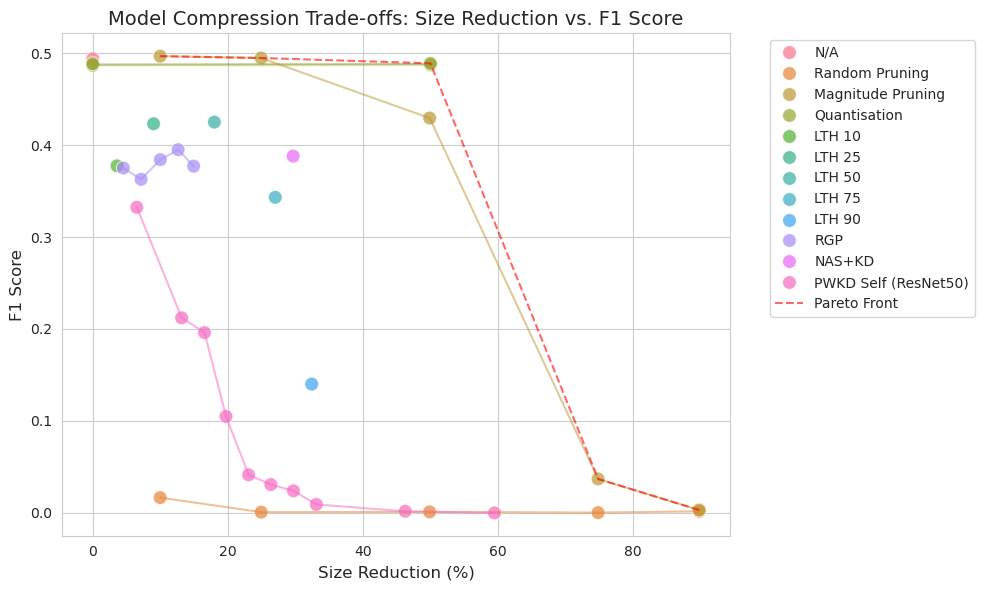

                  Method Base_Model Size_Reduction_Pct F1_Score
0                    N/A   resnet50                0.0   0.4938
1         Random Pruning   resnet50               9.98   0.0166
2      Magnitude Pruning   resnet50               9.98   0.4967
3         Random Pruning   resnet50              24.94   0.0008
4      Magnitude Pruning   resnet50              24.94   0.4947
5         Random Pruning   resnet50              49.89   0.0011
6      Magnitude Pruning   resnet50              49.89   0.4294
7         Random Pruning   resnet50              74.83   0.0003
8      Magnitude Pruning   resnet50              74.83   0.0369
9         Random Pruning   resnet50               89.8   0.0017
10     Magnitude Pruning   resnet50               89.8   0.0031
11          Quantisation   resnet50                0.0   0.4867
12          Quantisation   resnet50                0.0   0.4884
13          Quantisation   resnet50               50.0   0.4872
14          Quantisation   resnet50     

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df)

print(results_df)

In [90]:
# Use this for saving the results df to a csv file so we don't have to rerun everytime
results_df.to_csv("results_resnet50.csv", mode='a', header=True, index=False)

# <span style="color: green;">Algorithm Application to ResNet18</span>
This section applied all of our KD algorithms to a pretrained ResNet18.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: green;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [91]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet18 = loader.load_radimagenet_resnet18(
    "./trained_models/resnet18_baseline_gpu_new/resnet18_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet18 = resnet18.to(device)
resnet18.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet18.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet18, "ResNet18 gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet18 gpu new...
Running inference...
Our F1 score: 0.4110675749183641
Our total parameters: 11207805


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [92]:
# initialize a dataframe we will append our results to
results_df_resnet18 = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df_resnet18
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df_resnet18 = pd.concat([results_df_resnet18, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet18', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.411


## <span style="color: green;">b. Basic Compression Algorithms</span>

### Basic Pruning and Quantization

In [93]:
evaluator = ModelEvaluator(
    data_loader=data_prep.val_loader,
    class_names=data_prep.class_names
)

eval = run_quantisation_suite("ResNet18", resnet18, evaluator, quant_funcs)

base_model_size = eval.results['ResNet18_Baseline_FP32']['model_size_mb']

for name, results in eval.results.items():
    add_experiment(method=f'Quantisation {name}', 
                       base_model='resnet18',
                       base_size=base_model_size, 
                       compressed_size=results['model_size_mb'],
                       f1=results['f1_macro'])

--- Running on: CUDA ---
Preparing ResNet18_INT8_Dyn...
Preparing ResNet18_FP16...
Preparing ResNet18_INT8 and FP16...
Sending 4 models to the evaluator...

[Evaluating] ResNet18_Baseline_FP32...

Warming up ResNet18_Baseline_FP32...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

[Evaluating] ResNet18_INT8_Dyn...

Warming up ResNet18_INT8_Dyn...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

[Evaluating] ResNet18_FP16...

Warming up ResNet18_FP16...
Running inference...

[Evaluating] ResNet18_INT8 and FP16...

Warming up ResNet18_INT8 and FP16...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

+------------------------+------------+---------------------+--------------------+-------------------------+
| Model                  |   F1 Macro |   cuda Latency (ms) |   Actual Size (mb) |   Theoretical Size (mb) |
+========================+============+=====================+====================+=========================+
| ResNet18_Baseline_FP32 |       0.41 |                0.39 |              42.79 |                   42.79 |
+------------------------+------------+---------------------+--------------------+-------------------------+
| ResNet18_INT8_Dyn      |       0.41 |                0.42 |              42.79 |                   42.79 |
+------------------------+------------+---------------------+--------------------+-------------------------+
| ResNet18_FP16          |       0.41 |                0.24 |              21.4  |                   21.4  |
+------------------------+------------+---------------------+--------------------+------------------------

### Caylum - Lottery Ticket Hypothesis

In [94]:
# For ease, we set weights to zero instead of removing them outright so we use this function to count effective paramaters.
def count_effective_params(model):
    total = 0
    nonzero = 0
    
    for p in model.parameters():
        total += p.numel()
        nonzero += (p != 0).sum().item()
    
    return total, nonzero

In [95]:
import torch as T
import torch.nn.utils.prune as prune
from torchvision import models
import numpy as np
from modules import ImagenetLoader, datasetPrepper, modelTrainer, ModelEvaluator
import pandas as pd


# We need the weights path
lth_pretrained_weights_path = "RadImageNet_weights/resnet18.pth"

# Define the evaluator
lth_evaluator = ModelEvaluator(data_prep.val_loader, data_prep.class_names)
lth_loader = ImagenetLoader()
lth_eval_stats = {}
lth_param_counts = {}

# Define the pruning percentages
pruning_percentages = [10, 25, 50, 75, 90]

# Now loop for all pruning percentages
for p_percent in pruning_percentages:
    print(f"\nLTH for {p_percent}%")
    
    # Reset Weights at the start of every cycle
    lth_loader.load_radimagenet_resnet18(lth_pretrained_weights_path)
    lth_model = lth_loader.model
    
    # Train the parent model
    lth_trainer = modelTrainer(
        model=lth_model,
        data_prep=data_prep,
        device=None,
        learn_rate=0.001,
        num_epochs=10,
        model_name=f"parent_lth_{p_percent}",
    )
    lth_trainer.prepare_for_training(trainable_params=lth_loader.get_trainable_params())
    lth_trainer.train_all()
    
    # Get the pruning mask from the parent model
    lth_model.eval()
    masks = {}
    
    for name, module in lth_model.named_modules():
      if isinstance(module, (T.nn.Linear, T.nn.Conv2d)):
        prune.l1_unstructured(module, name='weight', amount=p_percent / 100.0)
        masks[name] = (module.weight_mask).cpu()
        prune.remove(module, 'weight')

    # Reset Weights
    lth_loader.load_radimagenet_resnet18(lth_pretrained_weights_path)
    lth_model = lth_loader.model
    lth_trainer = modelTrainer(
        model=lth_model,
        data_prep=data_prep,
        device=None,
        learn_rate=0.001,
        num_epochs=10,
        model_name=f"lth_{p_percent}",
    )

    # Apply the mask by directly setting weights to zero where mask is zero
    with T.no_grad():
      for name, module in lth_model.named_modules():
        if isinstance(module, (T.nn.Linear, T.nn.Conv2d)) and name in masks:
            module.weight.data.mul_(masks[name])
            prune.custom_from_mask(module, name='weight', mask=masks[name])
            prune.remove(module, 'weight')
    
    # Train that ticket
    print(f"Training ticket for {p_percent}% LTH pruning...")
    lth_model.train()
    lth_trainer.prepare_for_training(trainable_params=lth_loader.get_trainable_params())
    lth_trainer.train_all()

    # Evaluate that ticket
    lth_model.eval()
    lth_metrics = lth_evaluator.evaluate_single(lth_model)
    lth_total, lth_non_zero = count_effective_params(lth_model)
    
    # Add in the experiment
    add_experiment(method=f'LTH {p_percent}', 
               base_model='resnet18', 
               base_size=lth_total, 
               compressed_size=lth_non_zero, 
               f1=lth_metrics['f1_macro'])

    print(f"\n======================\nDone for %{p_percent}\n======================\n")


LTH for 10%


Validating: 100%|██████████| 50/50 [00:02<00:00, 19.09batch/s]



Epoch 1/10
Train Loss: 1.2317 | Train F1: 0.3339
Val Loss: 1.9001 | Val F1: 0.2416
Epoch Time: 26.92s



Validating: 100%|██████████| 50/50 [00:02<00:00, 19.06batch/s]



Epoch 2/10
Train Loss: 0.3589 | Train F1: 0.6114
Val Loss: 1.7001 | Val F1: 0.3458
Epoch Time: 26.94s



...

Validating: 100%|██████████| 50/50 [00:02<00:00, 18.91batch/s]



Epoch 9/10
Train Loss: 0.2742 | Train F1: 0.6357
Val Loss: 2.5002 | Val F1: 0.2697
Epoch Time: 26.98s



Validating: 100%|██████████| 50/50 [00:02<00:00, 18.92batch/s]


Epoch 10/10
Train Loss: 0.2293 | Train F1: 0.6673
Val Loss: 2.6300 | Val F1: 0.2787
Epoch Time: 27.00s


Warming up Model...


Running inference...
Logged: LTH 90 | Reduction: 22.3% | F1: 0.279

Done for %90



### Kellie - RGP

In [96]:
import os
import torch
import pandas as pd

rgp_checkpoints_r18 = {
    '10%': 'trained_models/resnet18_rgp_step_0.1/resnet18_rgp_step_0.1_full.pth',
    '20%': 'trained_models/resnet18_rgp_step_0.2/resnet18_rgp_step_0.2_full.pth',
    '30%': 'trained_models/resnet18_rgp_step_0.3/resnet18_rgp_step_0.3_full.pth',
    '40%': 'trained_models/resnet18_rgp_step_0.4/resnet18_rgp_step_0.4_full.pth',
    '50%': 'trained_models/resnet18_rgp_step_0.5/resnet18_rgp_step_0.5_full.pth',
}

initial_params_r18 = sum(p.numel() for p in resnet18.parameters())
rgp_step_metrics_r18 = []

for sparsity, path in rgp_checkpoints_r18.items():
    print(f"Loading ResNet18 RGP {sparsity} from {path}...")
    rgp_model = torch.load(path, map_location=device, weights_only=False)['model']
    rgp_model = rgp_model.to(device)
    rgp_model.eval()
    step_metrics = evaluator.evaluate_single(rgp_model, f"ResNet18_RGP_{sparsity}")
    step_params  = sum(p.numel() for p in rgp_model.parameters())
    add_experiment(method='RGP', base_model='resnet18', base_size=initial_params_r18, compressed_size=step_params, f1=step_metrics['f1_macro'])
    rgp_step_metrics_r18.append({
        'Sparsity': sparsity,
        'Size Reduction (%)': round(((initial_params_r18 - step_params) / initial_params_r18) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

summary_df_r18 = pd.DataFrame(rgp_step_metrics_r18).set_index('Sparsity')
summary_df_r18.index.name = 'RGP Step'
display(summary_df_r18)

Loading ResNet18 RGP 10% from trained_models/resnet18_rgp_step_0.1/resnet18_rgp_step_0.1_full.pth...

Warming up ResNet18_RGP_10%...
Running inference...
Logged: RGP | Reduction: 2.5% | F1: 0.381
Loading ResNet18 RGP 20% from trained_models/resnet18_rgp_step_0.2/resnet18_rgp_step_0.2_full.pth...

Warming up ResNet18_RGP_20%...
Running inference...
Logged: RGP | Reduction: 7.6% | F1: 0.347
Loading ResNet18 RGP 30% from trained_models/resnet18_rgp_step_0.3/resnet18_rgp_step_0.3_full.pth...

Warming up ResNet18_RGP_30%...
Running inference...
Logged: RGP | Reduction: 14.6% | F1: 0.335
Loading ResNet18 RGP 40% from trained_models/resnet18_rgp_step_0.4/resnet18_rgp_step_0.4_full.pth...

Warming up ResNet18_RGP_40%...
Running inference...
Logged: RGP | Reduction: 21.3% | F1: 0.321
Loading ResNet18 RGP 50% from trained_models/resnet18_rgp_step_0.5/resnet18_rgp_step_0.5_full.pth...

Warming up ResNet18_RGP_50%...
Running inference...
Logged: RGP | Reduction: 28.3% | F1: 0.305


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,2.53,0.3809,41.7,0.34
20%,7.59,0.3470,39.5,0.34
30%,14.64,0.3346,36.5,0.34
40%,21.26,0.3212,33.7,0.33
50%,28.29,0.3051,30.7,0.33


## <span style="color: green;">c. Knowledge Distillation Algorithms</span>

### Ethan - NAS + KD Algorithm

In [97]:
''' search space:
input resolution = [128, 160, 190, 224]
depth = [1, 2, 3]
width = [0.5, 0.75, 1.0, 1.2]
'''
# define a config class for supernet training
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet18'

        # supernet init params
        self.supernet_res = [128, 160, 190, 224]
        self.supernet_width = [0.5, 0.75, 1.0, 1.2]
        self.supernet_depth = [1, 2, 3]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 3.0
        self.alpha = 0.4
        
        self.saver = 'supernet_resnet18_n'

In [98]:
# import modules that will load our supernet
from knowledge_distillation.model_init import Supernet_resnet18
from knowledge_distillation.extraction_tools import extract_resnet18, verify_parity

# load finetuned supernet
config = SupernetConfig()
snet = Supernet_resnet18(config.supernet_width, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'trained_models/supernet_resnet18_n_polished.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

# define our winning config, determined by evolutionary search
winning_config = {
    'res': 128, 
    'width': 0.75, 
    'depth': [3, 2, 1, 2],
}

# extract our winning configuration from the supernet and confirm it loaded appropriately
student_r18 = extract_resnet18(snet, winning_config)
verify_parity(snet, student_r18, winning_config)

# instantiate our evaluator with the test dataset loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

# get our metrics and record our NAS KD experiment
metrics = evaluator.evaluate_single(student_r18)
print(f'\nStudent has parameters: {metrics['total_parameters']}')
add_experiment(method='NAS+KD',
               base_model='resnet18',
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=metrics['total_parameters'], 
               f1=metrics['f1_macro'])

Supernet loaded
Transitioning weights...
The models match! Test is passed.
Max difference: 4.77e-07

Student has parameters: 5694493
Logged: NAS+KD | Reduction: 49.2% | F1: 0.343


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ciara - PWKD

In [99]:
### Ciara - PWKD (both ResNet50 -> ResNet18, and self ResNet18)

# Ciara — PWKD 
import torch
import pandas as pd
from torchvision import models
import torch.nn as nn

_ref_r18 = models.resnet18(weights=None)
_ref_r18.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(512, 61))
R18_BASE_PARAMS = sum(p.numel() for p in _ref_r18.parameters())
del _ref_r18

# ── ResNet18 student distilling from ResNet50 teacher ───────────────
r18_checkpoints = {
    '10%': 'trained_models/pwkd_r18_r10/pwkd_r18_r10_full.pth',
    '20%': 'trained_models/pwkd_r18_r20/pwkd_r18_r20_full.pth',
    '25%': 'trained_models/pwkd_r18_r25/pwkd_r18_r25_full.pth',
    '30%': 'trained_models/pwkd_r18_r30/pwkd_r18_r30_full.pth',
    '35%': 'trained_models/pwkd_r18_r35/pwkd_r18_r35_full.pth',
    '40%': 'trained_models/pwkd_r18_r40/pwkd_r18_r40_full.pth',
    '45%': 'trained_models/pwkd_r18_r45/pwkd_r18_r45_full.pth',
    '50%': 'trained_models/pwkd_r18_r50/pwkd_r18_r50_full.pth',
    '70%': 'trained_models/pwkd_r18_r70/pwkd_r18_r70_full.pth',
    '90%': 'trained_models/pwkd_r18_r90/pwkd_r18_r90_full.pth',
}

evaluator = ModelEvaluator(data_prep.test_loader)

pwkd_r18_step_metrics = []
print('── PWKD ResNet18 student ──')
for sparsity, path in r18_checkpoints.items():
    print(f'Loading {path} ...')
    model = torch.load(path, map_location=device, weights_only=False)['model']
    model = model.to(device).eval()
    step_metrics = evaluator.evaluate_single(model, f'PWKD_R18_{sparsity}')
    step_params  = step_metrics['total_parameters']
    add_experiment(
        method='PWKD (ResNet18)',
        base_model='resnet18',
        base_size=R18_BASE_PARAMS,
        compressed_size=step_params,
        f1=step_metrics['f1_macro'],
    )
    pwkd_r18_step_metrics.append({
        'Ratio':              sparsity,
        'Size Reduction (%)': round((R18_BASE_PARAMS - step_params) / R18_BASE_PARAMS * 100, 2),
        'F1 Score':           round(step_metrics['f1_macro'], 4),
        'Size (MB)':          round(step_metrics['model_size_mb_theoretical'], 1),
        'Latency (ms)':       round(step_metrics['avg_latency_ms'], 2),
    })
    
r18_summary = pd.DataFrame(pwkd_r18_step_metrics).set_index('Ratio')
r18_summary.index.name = 'PWKD R18 Ratio'
display(r18_summary)

# ── ResNet18 self-pruning ──────────────────────────────────────────
self_r18_checkpoints = {
    '10%': 'trained_models/pwkd_self_r18_r10/pwkd_self_r18_r10_full.pth',
    '20%': 'trained_models/pwkd_self_r18_r20/pwkd_self_r18_r20_full.pth',
    '25%': 'trained_models/pwkd_self_r18_r25/pwkd_self_r18_r25_full.pth',
    '30%': 'trained_models/pwkd_self_r18_r30/pwkd_self_r18_r30_full.pth',
    '35%': 'trained_models/pwkd_self_r18_r35/pwkd_self_r18_r35_full.pth',
    '40%': 'trained_models/pwkd_self_r18_r40/pwkd_self_r18_r40_full.pth',
    '45%': 'trained_models/pwkd_self_r18_r45/pwkd_self_r18_r45_full.pth',
    '50%': 'trained_models/pwkd_self_r18_r50/pwkd_self_r18_r50_full.pth',
    '70%': 'trained_models/pwkd_self_r18_r70/pwkd_self_r18_r70_full.pth',
    '90%': 'trained_models/pwkd_self_r18_r90/pwkd_self_r18_r90_full.pth',
}



evaluator = ModelEvaluator(data_prep.test_loader)


self_pwkd_r18_step_metrics = []


print('\n── PWKD ResNet18 self pruning ──')
for sparsity, path in self_r18_checkpoints.items():
    print(f'Loading {path} ...')
    model = torch.load(path, map_location=device, weights_only=False)['model']
    model = model.to(device).eval()
    step_metrics = evaluator.evaluate_single(model, f'PWKD_SELF_R18_{sparsity}')
    step_params  = step_metrics['total_parameters']
    add_experiment(
        method='PWKD Self (ResNet18)',
        base_model='resnet18',
        base_size=R18_BASE_PARAMS,
        compressed_size=step_params,
        f1=step_metrics['f1_macro'],
    )
    self_pwkd_r18_step_metrics.append({
        'Ratio':              sparsity,
        'Size Reduction (%)': round((R18_BASE_PARAMS - step_params) / R18_BASE_PARAMS * 100, 2),
        'F1 Score':           round(step_metrics['f1_macro'], 4),
        'Size (MB)':          round(step_metrics['model_size_mb_theoretical'], 1),
        'Latency (ms)':       round(step_metrics['avg_latency_ms'], 2),
    })
self_r18_summary = pd.DataFrame(self_pwkd_r18_step_metrics).set_index('Ratio')
self_r18_summary.index.name = 'PWKD Self R18 Ratio'
display(self_r18_summary)

# results_df.to_csv('results.csv', mode='a', header=False, index=False)
# print('PWKD results appended to results.csv')

── PWKD ResNet18 student ──
Loading trained_models/pwkd_r18_r10/pwkd_r18_r10_full.pth ...

Warming up PWKD_R18_10%...
Running inference...
Logged: PWKD (ResNet18) | Reduction: 9.7% | F1: 0.335
Loading trained_models/pwkd_r18_r20/pwkd_r18_r20_full.pth ...

Warming up PWKD_R18_20%...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD (ResNet18) | Reduction: 19.5% | F1: 0.215
Loading trained_models/pwkd_r18_r25/pwkd_r18_r25_full.pth ...

Warming up PWKD_R18_25%...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD (ResNet18) | Reduction: 24.5% | F1: 0.223
Loading trained_models/pwkd_r18_r30/pwkd_r18_r30_full.pth ...

Warming up PWKD_R18_30%...


...

/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD Self (ResNet18) | Reduction: 49.0% | F1: 0.001
Loading trained_models/pwkd_self_r18_r70/pwkd_self_r18_r70_full.pth ...

Warming up PWKD_SELF_R18_70%...
Running inference...
Logged: PWKD Self (ResNet18) | Reduction: 68.5% | F1: 0.000
Loading trained_models/pwkd_self_r18_r90/pwkd_self_r18_r90_full.pth ...

Warming up PWKD_SELF_R18_90%...


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Running inference...
Logged: PWKD Self (ResNet18) | Reduction: 88.1% | F1: 0.000


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
PWKD Self R18 Ratio,,,,
10%,9.69,0.3462,38.6,0.40
20%,19.49,0.2413,34.5,0.39
25%,24.50,0.1776,32.3,0.38
30%,29.24,0.1463,30.3,0.39
35%,34.20,0.0476,28.2,0.39
40%,39.04,0.0091,26.1,0.40
45%,44.00,0.0087,24.0,0.40
50%,49.01,0.0008,21.8,0.40
70%,68.50,0.0000,13.5,0.40


## <span style="color: green;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

In [100]:
results_df_resnet18 = results_df_resnet18.replace(r"^Random Pruning.*", "Random Pruning", regex=True)
results_df_resnet18 = results_df_resnet18.replace(r"^Magnitude Pruning.*", "Magnitude Pruning", regex=True)
results_df_resnet18 = results_df_resnet18.replace(r"^Quantisation.*", "Quantisation", regex=True)

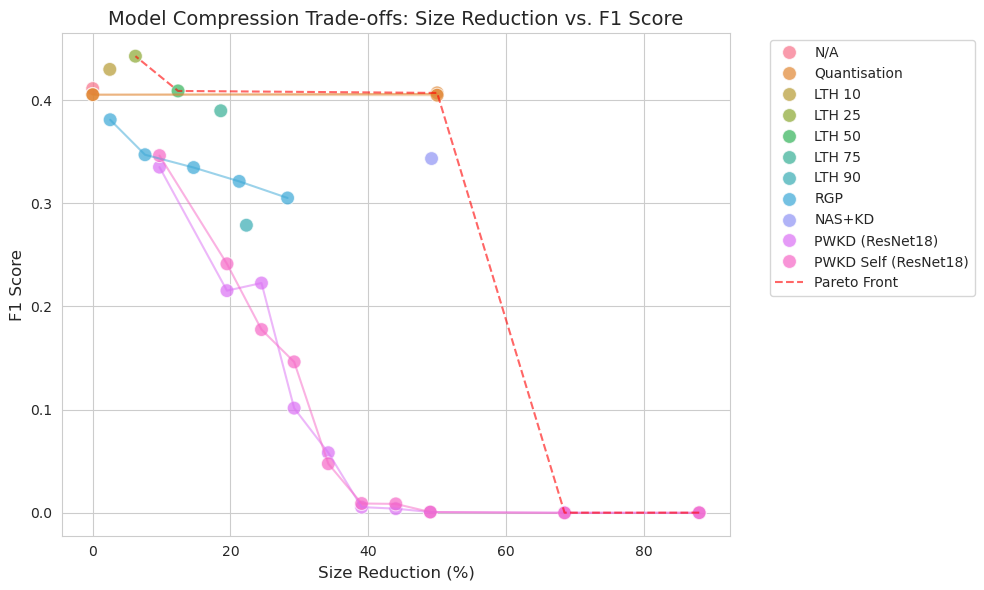

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df_resnet18)

In [102]:
# Use this for saving the results df to a csv file so we don't have to rerun everytime
results_df_resnet18.to_csv("results_resnet18.csv", mode='a', header=True, index=False)

# <span style="color: blue;">Algorithm Application to ResNet10t</span>
This section applied all of our KD algorithms to a pretrained ResNet10t.  It has subsections:\
a. <ins>Pretrained Model Loading:</ins> this pulls our pretrained model (to which we will apply our compression & KD algorithms)\
b. <ins>Basic Compression Algorithms:</ins> applies pruning, quantization, LTH, and RGP\
c. <ins>Knowledge Distillation Algorithms:</ins> applied our NAS + KD algorithm and Pruning with KD algorithm\
d. <ins>Final Comparison:</ins> illustrates the performance of our algorithms in a Pareto Front

## <span style="color: blue;">a. Pretrained Model Loading</span>
Section that loads the pretrained models - our baseline/teacher.  Requires your own huggingface token, used to log in above.

In [103]:
import torch
from modules.imagenet_loader import ImagenetLoader
from modules.evaluate_model import ModelEvaluator

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# initialize loader class that will bring in our pretrained model
loader = ImagenetLoader()
resnet10 = loader.load_radimagenet_resnet10t(
    "./trained_models/resnet10t_baseline_gpu_new/resnet10t_baseline_gpu_new.pth",
    load_type="load"
    )

# move teacher model to gpu
resnet10 = resnet10.to(device)
resnet10.eval()

# freeze teacher params, since we aren't doing any further training
for p in resnet10.parameters():
    p.requires_grad = False

# instantiate the model evaluator class with the test loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names)

# evaluate our teacher
base_model_metrics = evaluator.evaluate_single(resnet10, "ResNet10t gpu new")
print(f"Our F1 score: {base_model_metrics['f1_macro']}\nOur total parameters: {base_model_metrics['total_parameters']}")


Warming up ResNet10t gpu new...
Running inference...
Our F1 score: 0.29770593570914206
Our total parameters: 4953781


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [104]:
# initialize a dataframe we will append our results to
results_df_resnet10 = pd.DataFrame(columns=[
    'Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'
])

# function that can easily add results to the df
def add_experiment(method, base_model, base_size, compressed_size, f1):
    global results_df_resnet10
    reduction = ((base_size - compressed_size) / base_size) * 100
    
    new_entry = {
        'Method': method,
        'Base_Model': base_model,
        'Size_Reduction_Pct': round(reduction, 2),
        'F1_Score': round(f1, 4),
    }
    
    results_df_resnet10 = pd.concat([results_df_resnet10, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"Logged: {method} | Reduction: {reduction:.1f}% | F1: {f1:.3f}")

# add out baseline model's metrics to the dataframe
add_experiment(method='N/A', 
               base_model='resnet10t', 
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=base_model_metrics['total_parameters'], 
               f1=base_model_metrics['f1_macro'])

Logged: N/A | Reduction: 0.0% | F1: 0.298


## <span style="color: blue;">b. Basic Compression Algorithms</span>

### Basic Pruning and Quantization

In [105]:
evaluator = ModelEvaluator(
    data_loader=data_prep.val_loader,
    class_names=data_prep.class_names
)

eval = run_quantisation_suite("ResNet10", resnet10, evaluator, quant_funcs)

base_model_size = eval.results['ResNet10_Baseline_FP32']['model_size_mb']

for name, results in eval.results.items():
    add_experiment(method=f'Quantisation {name}', 
                       base_model='resnet10',
                       base_size=base_model_size, 
                       compressed_size=results['model_size_mb'],
                       f1=results['f1_macro'])

--- Running on: CUDA ---
Preparing ResNet10_INT8_Dyn...
Preparing ResNet10_FP16...
Preparing ResNet10_INT8 and FP16...
Sending 4 models to the evaluator...

[Evaluating] ResNet10_Baseline_FP32...

Warming up ResNet10_Baseline_FP32...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

[Evaluating] ResNet10_INT8_Dyn...

Warming up ResNet10_INT8_Dyn...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

[Evaluating] ResNet10_FP16...

Warming up ResNet10_FP16...
Running inference...

[Evaluating] ResNet10_INT8 and FP16...

Warming up ResNet10_INT8 and FP16...


/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/uintx/plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
/home/epoc2/.local/lib/python3.13/site-packages/torchao/dtypes/utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


Running inference...

+------------------------+------------+---------------------+--------------------+-------------------------+
| Model                  |   F1 Macro |   cuda Latency (ms) |   Actual Size (mb) |   Theoretical Size (mb) |
+========================+============+=====================+====================+=========================+
| ResNet10_Baseline_FP32 |       0.32 |                0.35 |              18.92 |                   18.92 |
+------------------------+------------+---------------------+--------------------+-------------------------+
| ResNet10_INT8_Dyn      |       0.32 |                0.37 |              18.92 |                   18.92 |
+------------------------+------------+---------------------+--------------------+-------------------------+
| ResNet10_FP16          |       0.32 |                0.18 |               9.46 |                    9.46 |
+------------------------+------------+---------------------+--------------------+------------------------

### Caylum - Lottery Ticket Hypothesis

### Kellie - RGP

In [106]:
import os
import torch
import pandas as pd

rgp_checkpoints_r10 = {
    '10%': 'trained_models/resnet10t_rgp_step_0.1/resnet10t_rgp_step_0.1_full.pth',
    '20%': 'trained_models/resnet10t_rgp_step_0.2/resnet10t_rgp_step_0.2_full.pth',
    '30%': 'trained_models/resnet10t_rgp_step_0.3/resnet10t_rgp_step_0.3_full.pth',
    '40%': 'trained_models/resnet10t_rgp_step_0.4/resnet10t_rgp_step_0.4_full.pth',
    '50%': 'trained_models/resnet10t_rgp_step_0.5/resnet10t_rgp_step_0.5_full.pth',
}

initial_params_r10 = sum(p.numel() for p in resnet10.parameters())
rgp_step_metrics_r10 = []

for sparsity, path in rgp_checkpoints_r10.items():
    print(f"Loading ResNet10t RGP {sparsity} from {path}...")
    rgp_model = torch.load(path, map_location=device, weights_only=False)['model']
    rgp_model = rgp_model.to(device)
    rgp_model.eval()
    step_metrics = evaluator.evaluate_single(rgp_model, f"ResNet10t_RGP_{sparsity}")
    step_params  = sum(p.numel() for p in rgp_model.parameters())
    add_experiment(method='RGP', base_model='resnet10t', base_size=initial_params_r10, compressed_size=step_params, f1=step_metrics['f1_macro'])
    rgp_step_metrics_r10.append({
        'Sparsity': sparsity,
        'Size Reduction (%)': round(((initial_params_r10 - step_params) / initial_params_r10) * 100, 2),
        'F1 Score': round(step_metrics['f1_macro'], 4),
        'Size (MB)': round(step_metrics['model_size_mb'], 1),
        'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
    })

summary_df_r10 = pd.DataFrame(rgp_step_metrics_r10).set_index('Sparsity')
summary_df_r10.index.name = 'RGP Step'
display(summary_df_r10)

Loading ResNet10t RGP 10% from trained_models/resnet10t_rgp_step_0.1/resnet10t_rgp_step_0.1_full.pth...

Warming up ResNet10t_RGP_10%...
Running inference...
Logged: RGP | Reduction: 3.3% | F1: 0.308
Loading ResNet10t RGP 20% from trained_models/resnet10t_rgp_step_0.2/resnet10t_rgp_step_0.2_full.pth...

Warming up ResNet10t_RGP_20%...
Running inference...
Logged: RGP | Reduction: 8.4% | F1: 0.297
Loading ResNet10t RGP 30% from trained_models/resnet10t_rgp_step_0.3/resnet10t_rgp_step_0.3_full.pth...

Warming up ResNet10t_RGP_30%...
Running inference...
Logged: RGP | Reduction: 16.1% | F1: 0.308
Loading ResNet10t RGP 40% from trained_models/resnet10t_rgp_step_0.4/resnet10t_rgp_step_0.4_full.pth...

Warming up ResNet10t_RGP_40%...
Running inference...
Logged: RGP | Reduction: 21.7% | F1: 0.285
Loading ResNet10t RGP 50% from trained_models/resnet10t_rgp_step_0.5/resnet10t_rgp_step_0.5_full.pth...

Warming up ResNet10t_RGP_50%...
Running inference...
Logged: RGP | Reduction: 27.6% | F1: 0.2

,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,3.27,0.3082,18.3,0.34
20%,8.41,0.2966,17.3,0.32
30%,16.06,0.3076,15.9,0.30
40%,21.69,0.2852,14.8,0.32
50%,27.60,0.2750,13.7,0.29


## <span style="color: blue;">c. Knowledge Distillation Algorithms</span>

### Ethan - NAS + KD Algorithm

In [107]:
''' search space:
input resolution = [112, 128, 160, 224]
depth = [1, 2, 3]
width = [0.5, 0.75, 1.0, 1.2]
'''
class SupernetConfig:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.teacher_name = 'resnet10'

        # supernet init params
        self.supernet_res = [112, 128, 160, 224]
        self.supernet_width = [0.5, 0.75, 1.0, 1.2]
        self.supernet_depth = [1, 2]
        self.num_data_classes = 61
        
        # training params
        self.batch_size = 32
        self.epochs = 60
        self.warmup_epochs=15
        self.paths_sampled=20  # per greedyNAS
        self.peak_lr = 0.05
        
        # distillation loss params
        self.temperature = 2.0
        self.alpha = 0.2
        
        self.saver = 'supernet_resnet10_n'

In [108]:
# import modules that will load our supernet
from knowledge_distillation.model_init import Supernet_resnet10
from knowledge_distillation.extraction_tools import extract_resnet10, verify_parity

# load finetuned supernet
config = SupernetConfig()
snet = Supernet_resnet10(config.supernet_width, num_classes=config.num_data_classes).to(config.device)
checkpoint = torch.load(f'trained_models/supernet_resnet10_n_polished.pth', map_location=config.device)
snet.load_state_dict(checkpoint['model_state_dict'])
print(f"Supernet loaded")

# define our winning config, determined by evolutionary search
winning_config = {
    'res': 128, 
    'width': 0.5, 
    'depth': [2, 2, 2, 2],
    }

# extract our winning configuration from the supernet and confirm it loaded appropriately
standalone_r10 = extract_resnet10(snet, winning_config)
verify_parity(snet, standalone_r10, winning_config)

# instantiate our evaluator with the test dataset loader
evaluator = ModelEvaluator(data_loader=data_prep.test_loader, class_names=data_prep.class_names, silent=True)

# get our metrics and record our NAS KD experiment
metrics = evaluator.evaluate_single(standalone_r10)
print(f'\nStudent model has parameters: {metrics['total_parameters']}')
add_experiment(method='NAS+KD',
               base_model='resnet10t',
               base_size=base_model_metrics['total_parameters'], 
               compressed_size=metrics['total_parameters'], 
               f1=metrics['f1_macro'])


Supernet loaded
Slicing weights for width 0.5 and depth [2, 2, 2, 2]...
The models match! Test is passed.
Max difference: 2.38e-07

Student model has parameters: 2819693
Logged: NAS+KD | Reduction: 43.1% | F1: 0.331


/home/epoc2/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ciara - PWKD

## <span style="color: blue;">d. Final Comparison</span>
Illustrates the performance of our algorithms with a Pareto Front

In [109]:
results_df_resnet10 = results_df_resnet10.replace(r"^Random Pruning.*", "Random Pruning", regex=True)
results_df_resnet10 = results_df_resnet10.replace(r"^Magnitude Pruning.*", "Magnitude Pruning", regex=True)
results_df_resnet10 = results_df_resnet10.replace(r"^Quantisation.*", "Quantisation", regex=True)

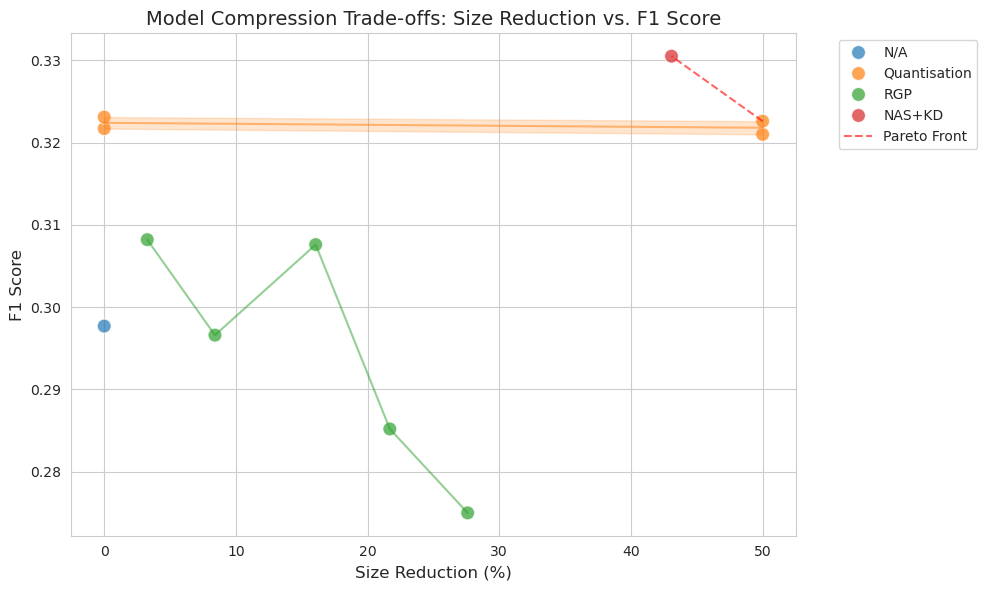

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compression_pareto(df):
    # first we sort by size - want to find points where F1 is the highest for a given reduction level to determine pareto front
    df_sorted = df.sort_values(by='Size_Reduction_Pct')
    pareto_reduction = []
    pareto_f1 = []
    current_max_f1 = -1
    
    # iterate through them to find the best point
    # higher reduction AND higher/equal F1 than previous points
    for _, row in df_sorted.iloc[::-1].iterrows():
        if row['F1_Score'] >= current_max_f1:
            pareto_reduction.append(row['Size_Reduction_Pct'])
            pareto_f1.append(row['F1_Score'])
            current_max_f1 = row['F1_Score']

    # set up plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    scatter = sns.scatterplot(  # plots all experiments
        data=df, 
        x='Size_Reduction_Pct', 
        y='F1_Score', 
        hue='Method', 
        s=100, 
        alpha=0.7
    )

    sns.lineplot(
        data=df,
        x='Size_Reduction_Pct',
        y='F1_Score',
        hue='Method',
        alpha=0.5,
        legend=False
    )
    
    # visualizes pareto frontier line
    plt.plot(pareto_reduction, pareto_f1, color='red', linestyle='--', alpha=0.6, label='Pareto Front')
    
    # add labels and whatnot
    plt.title('Model Compression Trade-offs: Size Reduction vs. F1 Score', fontsize=14)
    plt.xlabel('Size Reduction (%)', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.show()
plot_compression_pareto(results_df_resnet10)

In [111]:
# Use this for saving the results df to a csv file so we don't have to rerun everytime
results_df_resnet10.to_csv("results_resnet10.csv", mode='a', header=True, index=False)

In [ ]:
# Thank you!